In [ ]:
!pip install river

In [ ]:
import os
import zipfile
import urllib.request
import random
import logging

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import mean_squared_error, r2_score, confusion_matrix, classification_report, accuracy_score

In [ ]:
try:
    from river import forest
    ARFRegressor = forest.ARFRegressor
except ImportError:
    from river import ensemble
    ARFRegressor = ensemble.AdaptiveRandomForestRegressor

from river import tree, linear_model, optim as river_optim

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

In [ ]:
URL = "https://data.nasa.gov/docs/legacy/CMAPSSData.zip"
ZIP_PATH = "CMAPSSData.zip"
EXTRACT_DIR = "CMAPSSData"
TRAIN_FILE = os.path.join(EXTRACT_DIR, "train_FD001.txt")

if not os.path.exists(TRAIN_FILE):
    if not os.path.exists(EXTRACT_DIR):
        logger.info("Downloading NASA C-MAPSS dataset...")
        try:
            urllib.request.urlretrieve(URL, ZIP_PATH)
            with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
                zip_ref.extractall(EXTRACT_DIR)
            os.remove(ZIP_PATH)
            logger.info("Data extraction completed successfully.")
        except Exception as exc:
            raise RuntimeError(
                "Could not download the C-MAPSS dataset automatically "
                f"({exc}). The NASA host has been intermittently unavailable. "
                "Download it manually (e.g. from the Kaggle mirror "
                "'behrad3d/nasa-cmaps' or the PCoE repository) and place "
                f"train_FD001.txt at: {TRAIN_FILE}"
            ) from exc
    if not os.path.exists(TRAIN_FILE):
        raise FileNotFoundError(f"Expected data file not found at {TRAIN_FILE}")
else:
    logger.info("Local data repository detected. Ingestion step bypassed.")

In [ ]:
logger.info("Executing target engineering and feature scaling.")
INDEX_NAMES = ['unit_number', 'time_cycle']
SETTING_NAMES = ['setting_1', 'setting_2', 'setting_3']
SENSOR_NAMES = [f'sensor_{i}' for i in range(1, 22)]
COL_NAMES = INDEX_NAMES + SETTING_NAMES + SENSOR_NAMES  # 26 columns

# NOTE (fix): the raw C-MAPSS files have trailing whitespace on every line,
# which some pandas/engine combinations read as an extra phantom column of
# NaNs. Reading without pre-assigned names and then slicing to the first 26
# columns avoids a "Length mismatch" error regardless of pandas version.
df = pd.read_csv(TRAIN_FILE, sep=r"\s+", header=None, engine="python")
df = df.iloc[:, :26]
df.columns = COL_NAMES

# Piece-wise linear RUL target, capped at 125 cycles
max_cycles = df.groupby('unit_number')['time_cycle'].max().reset_index()
max_cycles.columns = ['unit_number', 'max_cycle']
df = df.merge(max_cycles, on='unit_number', how='left')
df['RUL_linear'] = df['max_cycle'] - df['time_cycle']

RUL_MAX_CAP = 125
df['Target_RUL'] = df['RUL_linear'].clip(upper=RUL_MAX_CAP)
df = df.drop(columns=['max_cycle', 'RUL_linear'])

# Prune invariant (zero-variance) features
features_to_check = SETTING_NAMES + SENSOR_NAMES
constant_features = [col for col in features_to_check if df[col].nunique() <= 1]
df_clean = df.drop(columns=constant_features)
active_features = [col for col in df_clean.columns if col not in ['unit_number', 'time_cycle', 'Target_RUL']]
logger.info(f"Retained {len(active_features)} active features after pruning: {constant_features}")

# Global min-max scaling to [0, 1]
X_raw = df_clean[active_features].values.astype(np.float64)
y_raw = df_clean['Target_RUL'].values.astype(np.float64)
X_min, X_max = X_raw.min(axis=0), X_raw.max(axis=0)
X_max = np.where(X_max == X_min, X_min + 1e-5, X_max)
X_scaled = (X_raw - X_min) / (X_max - X_min)

In [ ]:
class FeatureSubNetwork(nn.Module):
    """Bagged sub-network for one feature: K small MLP "heads" whose outputs
    are averaged. This reduces variance vs. a single narrow MLP while still
    producing ONE scalar function of ONE input feature, so the glass-box
    f_i(x_i) shape-function plots later in this notebook are unaffected —
    we simply plot the averaged head output exactly as before."""
    def __init__(self, n_heads=3, hidden1=48, hidden2=24):
        super().__init__()
        self.heads = nn.ModuleList([
            nn.Sequential(
                nn.Linear(1, hidden1),
                nn.ReLU(),
                nn.Linear(hidden1, hidden2),
                nn.ReLU(),
                nn.Linear(hidden2, 1),
            )
            for _ in range(n_heads)
        ])

    def forward(self, x):
        outs = torch.stack([head(x) for head in self.heads], dim=0)  # (K, batch, 1)
        return outs.mean(dim=0)


class StreamingNAMWithReplay(nn.Module):
    """Neural Additive Model: y_hat = beta_0 + sum_i f_i(x_i)."""
    def __init__(self, num_features, n_heads=3):
        super().__init__()
        self.feature_nets = nn.ModuleList([FeatureSubNetwork(n_heads=n_heads) for _ in range(num_features)])
        self.global_bias = nn.Parameter(torch.zeros(1))

    def forward(self, x):
        feature_contributions = [net(x[:, i:i + 1]) for i, net in enumerate(self.feature_nets)]
        stacked = torch.stack(feature_contributions, dim=1)      # (batch, D, 1)
        summed = torch.sum(stacked, dim=1).squeeze(-1)           # (batch,)
        return summed + self.global_bias, feature_contributions


streaming_nam = StreamingNAMWithReplay(num_features=len(active_features), n_heads=3)
nam_optimizer = optim.Adam(streaming_nam.parameters(), lr=0.002, weight_decay=1e-5)
nam_scheduler = optim.lr_scheduler.StepLR(nam_optimizer, step_size=4000, gamma=0.5)
# Huber loss: quadratic near zero, linear for large errors -> less dominated
# by the (rarer) large-RUL early-life samples than plain MSE.
nam_criterion = nn.SmoothL1Loss(beta=5.0)

GRAD_UPDATES_PER_STEP = 3  # multiple replay updates per new sample; still only ever
                            # trains on samples whose true label has already been revealed


class ExperienceBuffer:
    """Reservoir-style memory buffer with error-weighted (prioritized) sampling:
    harder / higher-error past examples are replayed more often, on top of the
    original catastrophic-forgetting mitigation."""
    def __init__(self, max_size=3000):
        self.buffer = []
        self.priorities = []
        self.max_size = max_size

    def add(self, x, y, priority=1.0):
        if len(self.buffer) >= self.max_size:
            idx = random.randint(0, len(self.buffer) - 1)
            self.buffer[idx] = (x, y)
            self.priorities[idx] = priority
        else:
            self.buffer.append((x, y))
            self.priorities.append(priority)

    def sample(self, batch_size=64):
        if not self.buffer:
            return []
        weights = np.array(self.priorities, dtype=np.float64) + 1e-3
        probs = weights / weights.sum()
        n = min(len(self.buffer), batch_size)
        idxs = np.random.choice(len(self.buffer), size=n, replace=False, p=probs)
        return [self.buffer[i] for i in idxs]


replay_memory = ExperienceBuffer(max_size=3000)
streaming_arf_ensemble = ARFRegressor(n_models=15, seed=42)  # unchanged - fair baseline

# Baseline models representing "previously existing" simpler streaming
# approaches, run through the exact same prequential protocol so the
# comparison against the proposed NAM is apples-to-apples. Left unchanged.
baseline_hoeffding_tree = tree.HoeffdingTreeRegressor()
baseline_linear_reg = linear_model.LinearRegression(optimizer=river_optim.SGD(lr=0.01))

In [ ]:
logger.info("Executing prequential validation cycle.")

eval_logs = {
    'streaming_nam': {'preds': [], 'ae': [], 'mae_trace': [], '_sum_ae': 0.0},
    'arf_ensemble': {'preds': [], 'ae': [], 'mae_trace': [], '_sum_ae': 0.0},
    'hoeffding_tree': {'preds': [], 'ae': [], 'mae_trace': [], '_sum_ae': 0.0},
    'linear_reg': {'preds': [], 'ae': [], 'mae_trace': [], '_sum_ae': 0.0},
}

X_stream_tensor = torch.tensor(X_scaled, dtype=torch.float32)
y_stream_tensor = torch.tensor(y_raw, dtype=torch.float32)
n_steps = len(X_stream_tensor)

for step in range(n_steps):
    x_instance = X_stream_tensor[step:step + 1]
    y_actual_val = y_stream_tensor[step].item()
    x_dict = {f"f_{k}": val.item() for k, val in enumerate(x_instance[0])}

    # --- PHASE 1: PREDICT (using weights/state from before this step) ---
    with torch.no_grad():
        nam_pred, _ = streaming_nam(x_instance)
        nam_pred_val = max(0.0, min(125.0, nam_pred.item()))

    arf_pred_val = streaming_arf_ensemble.predict_one(x_dict)
    if arf_pred_val is None:  # river returns None before the model has seen any data
        arf_pred_val = 0.0
    arf_pred_val = max(0.0, min(125.0, arf_pred_val))

    hoeffding_pred_val = baseline_hoeffding_tree.predict_one(x_dict)
    if hoeffding_pred_val is None:
        hoeffding_pred_val = 0.0
    hoeffding_pred_val = max(0.0, min(125.0, hoeffding_pred_val))

    linear_pred_val = baseline_linear_reg.predict_one(x_dict)
    if linear_pred_val is None:
        linear_pred_val = 0.0
    linear_pred_val = max(0.0, min(125.0, linear_pred_val))

    for key, pred_val in (
        ('streaming_nam', nam_pred_val),
        ('arf_ensemble', arf_pred_val),
        ('hoeffding_tree', hoeffding_pred_val),
        ('linear_reg', linear_pred_val),
    ):
        ae = abs(pred_val - y_actual_val)
        log = eval_logs[key]
        log['preds'].append(pred_val)
        log['ae'].append(ae)
        log['_sum_ae'] += ae
        log['mae_trace'].append(log['_sum_ae'] / (step + 1))

    # --- PHASE 2: LEARN (reveal y_t, then update) ---
    step_error = abs(nam_pred_val - y_actual_val)
    replay_memory.add(X_scaled[step], y_actual_val, priority=step_error)

    for _ in range(GRAD_UPDATES_PER_STEP):
        minibatch = replay_memory.sample(batch_size=64)
        if not minibatch:
            break
        x_batch = torch.tensor(np.array([item[0] for item in minibatch]), dtype=torch.float32)
        y_batch = torch.tensor([item[1] for item in minibatch], dtype=torch.float32)

        streaming_nam.train()
        nam_optimizer.zero_grad()
        batch_preds, _ = streaming_nam(x_batch)
        loss = nam_criterion(batch_preds, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(streaming_nam.parameters(), max_norm=5.0)
        nam_optimizer.step()
        nam_scheduler.step()

    streaming_arf_ensemble.learn_one(x_dict, y_actual_val)
    baseline_hoeffding_tree.learn_one(x_dict, y_actual_val)
    baseline_linear_reg.learn_one(x_dict, y_actual_val)

    if (step + 1) % 5000 == 0:
        logger.info(f"Processed {step + 1}/{n_steps} stream steps.")

logger.info("Prequential stream parsing completed.")

In [ ]:
regression_results = []
for model_name, data in eval_logs.items():
    preds_arr = np.array(data['preds'])
    mae = np.mean(np.abs(y_raw - preds_arr))
    rmse = np.sqrt(mean_squared_error(y_raw, preds_arr))
    r2 = r2_score(y_raw, preds_arr)
    regression_results.append({
        'Model Architecture': model_name.upper(),
        'MAE (Cycles)': round(mae, 4),
        'RMSE (Cycles)': round(rmse, 4),
        'R2 Score (Variance Fit)': round(r2, 4),
    })

df_regression = pd.DataFrame(regression_results)
print("\n--- CONTINUOUS REGRESSION PERFORMANCE METRICS ---")
print(df_regression.to_string(index=False))


def map_to_operational_alerts(arr):
    return np.select(
        [arr <= 20, arr <= 60],
        [0, 1],
        default=2,
    )


y_true_alerts = map_to_operational_alerts(y_raw)
MODEL_DISPLAY_NAMES = {
    'streaming_nam': 'STREAMING_NAM (proposed)',
    'arf_ensemble': 'ARF_ENSEMBLE (SOTA baseline)',
    'hoeffding_tree': 'HOEFFDING_TREE (prior baseline)',
    'linear_reg': 'STREAMING_LINEAR_REG (prior baseline)',
}

classification_results = []
alert_preds_by_model = {}
for key, display_name in MODEL_DISPLAY_NAMES.items():
    alerts = map_to_operational_alerts(np.array(eval_logs[key]['preds']))
    alert_preds_by_model[key] = alerts
    acc = accuracy_score(y_true_alerts, alerts)
    classification_results.append({'Model Architecture': display_name, 'Global Classification Accuracy': f"{acc * 100:.2f}%"})

df_classification = pd.DataFrame(classification_results).sort_values(
    'Global Classification Accuracy', ascending=False
)
print("\n--- DISCRETE ALARM CLASSIFICATION ACCURACY SUMMARY (proposed vs. prior models) ---")
print(df_classification.to_string(index=False))

ALERT_LABELS = ['Critical Status', 'Warning Phase', 'Stable Operation']
print("\n--- DETAILED CLASSIFICATION REPORT (STREAMING NAM — proposed model) ---")
print(classification_report(y_true_alerts, alert_preds_by_model['streaming_nam'], target_names=ALERT_LABELS, labels=[0, 1, 2]))


--- CONTINUOUS REGRESSION PERFORMANCE METRICS ---
Model Architecture  MAE (Cycles)  RMSE (Cycles)  R2 Score (Variance Fit)
     STREAMING_NAM       14.4996        19.8436                   0.7733
      ARF_ENSEMBLE        4.8280         8.8694                   0.9547
    HOEFFDING_TREE       10.8646        16.0051                   0.8525
        LINEAR_REG        6.3731        10.1056                   0.9412

--- DISCRETE ALARM CLASSIFICATION ACCURACY SUMMARY (proposed vs. prior models) ---
                   Model Architecture Global Classification Accuracy
         ARF_ENSEMBLE (SOTA baseline)                         95.59%
STREAMING_LINEAR_REG (prior baseline)                         95.23%
      HOEFFDING_TREE (prior baseline)                         91.08%
             STREAMING_NAM (proposed)                         86.71%

--- DETAILED CLASSIFICATION REPORT (STREAMING NAM — proposed model) ---
                  precision    recall  f1-score   support

 Critical Status       

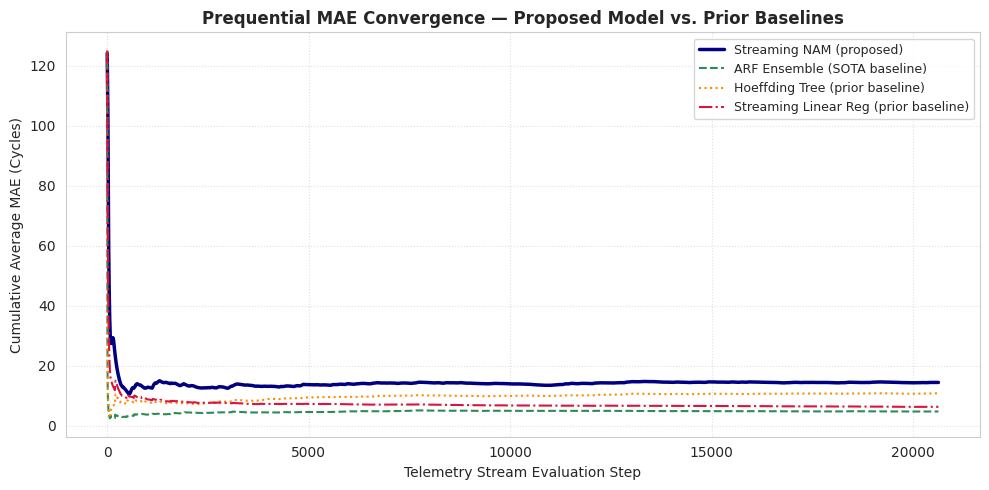

In [ ]:
sns.set_style("whitegrid")
nam_alerts = alert_preds_by_model['streaming_nam']
nam_accuracy = accuracy_score(y_true_alerts, nam_alerts)
cm_nam = confusion_matrix(y_true_alerts, nam_alerts, labels=[0, 1, 2])

plt.figure(figsize=(10, 5))
plt.plot(eval_logs['streaming_nam']['mae_trace'], label='Streaming NAM (proposed)', color='navy', linewidth=2.5)
plt.plot(eval_logs['arf_ensemble']['mae_trace'], label='ARF Ensemble (SOTA baseline)', color='seagreen', linestyle='--', linewidth=1.5)
plt.plot(eval_logs['hoeffding_tree']['mae_trace'], label='Hoeffding Tree (prior baseline)', color='darkorange', linestyle=':', linewidth=1.5)
plt.plot(eval_logs['linear_reg']['mae_trace'], label='Streaming Linear Reg (prior baseline)', color='crimson', linestyle='-.', linewidth=1.5)
plt.title('Prequential MAE Convergence — Proposed Model vs. Prior Baselines', fontsize=12, fontweight='bold')
plt.xlabel('Telemetry Stream Evaluation Step', fontsize=10)
plt.ylabel('Cumulative Average MAE (Cycles)', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

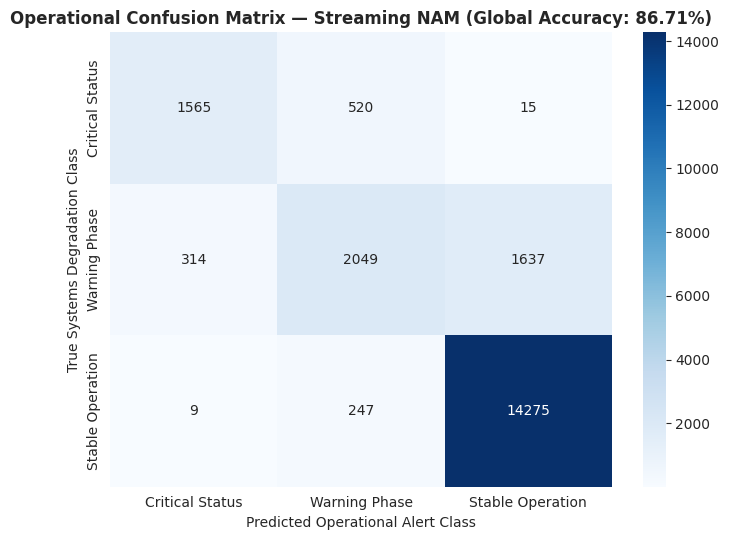

In [ ]:
plt.figure(figsize=(7, 5.5))
sns.heatmap(cm_nam, annot=True, fmt='d', cmap='Blues', xticklabels=ALERT_LABELS, yticklabels=ALERT_LABELS, cbar=True)
plt.title(f"Operational Confusion Matrix — Streaming NAM (Global Accuracy: {nam_accuracy * 100:.2f}%)", fontsize=12, fontweight='bold')
plt.xlabel('Predicted Operational Alert Class', fontsize=10)
plt.ylabel('True Systems Degradation Class', fontsize=10)
plt.tight_layout()
plt.show()

logger.info("Graphics displayed: prequential MAE convergence profile (all models) and operational confusion matrix.")


--- SAMPLE MODEL OUTPUT (Engine Unit 1, first & last 5 cycles) ---
 cycle  true_RUL  nam_pred_RUL (proposed)  arf_pred_RUL (SOTA baseline)  hoeffding_pred_RUL (prior)  linear_pred_RUL (prior)
     1     125.0                     0.82                          0.00                        0.00                     0.00
     2     125.0                     2.97                         77.51                       12.92                    12.92
     3     125.0                     4.93                        125.00                      125.00                    23.80
     4     125.0                     6.83                        125.00                      125.00                    34.79
     5     125.0                     8.76                        125.00                      125.00                    43.32
   188       4.0                     3.15                          3.74                        9.74                     9.74
   189       3.0                     0.00                

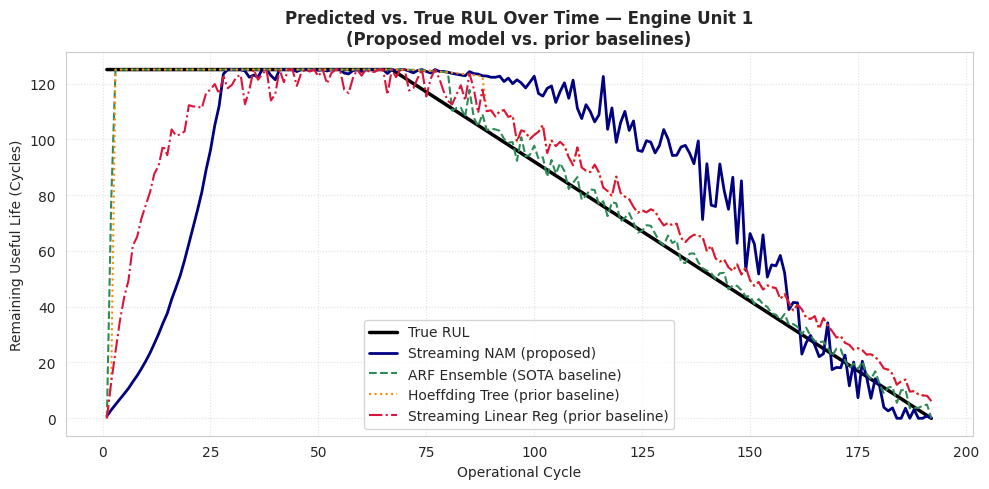

In [ ]:
unit_ids = df_clean['unit_number'].values
example_unit = int(np.unique(unit_ids)[0])  # first engine in the dataset; change as desired
mask = unit_ids == example_unit

cycles = df_clean['time_cycle'].values[mask]
true_rul = y_raw[mask]
nam_pred_rul = np.array(eval_logs['streaming_nam']['preds'])[mask]
arf_pred_rul = np.array(eval_logs['arf_ensemble']['preds'])[mask]
hoeffding_pred_rul = np.array(eval_logs['hoeffding_tree']['preds'])[mask]
linear_pred_rul = np.array(eval_logs['linear_reg']['preds'])[mask]

# Print a small sample table of raw predictions vs ground truth, proposed vs prior models
sample_df = pd.DataFrame({
    'cycle': cycles,
    'true_RUL': true_rul,
    'nam_pred_RUL (proposed)': np.round(nam_pred_rul, 2),
    'arf_pred_RUL (SOTA baseline)': np.round(arf_pred_rul, 2),
    'hoeffding_pred_RUL (prior)': np.round(hoeffding_pred_rul, 2),
    'linear_pred_RUL (prior)': np.round(linear_pred_rul, 2),
})
print(f"\n--- SAMPLE MODEL OUTPUT (Engine Unit {example_unit}, first & last 5 cycles) ---")
print(pd.concat([sample_df.head(5), sample_df.tail(5)]).to_string(index=False))

plt.figure(figsize=(10, 5))
plt.plot(cycles, true_rul, label='True RUL', color='black', linewidth=2.5)
plt.plot(cycles, nam_pred_rul, label='Streaming NAM (proposed)', color='navy', linewidth=2)
plt.plot(cycles, arf_pred_rul, label='ARF Ensemble (SOTA baseline)', color='seagreen', linestyle='--')
plt.plot(cycles, hoeffding_pred_rul, label='Hoeffding Tree (prior baseline)', color='darkorange', linestyle=':')
plt.plot(cycles, linear_pred_rul, label='Streaming Linear Reg (prior baseline)', color='crimson', linestyle='-.')
plt.title(f'Predicted vs. True RUL Over Time — Engine Unit {example_unit}\n(Proposed model vs. prior baselines)', fontsize=12, fontweight='bold')
plt.xlabel('Operational Cycle', fontsize=10)
plt.ylabel('Remaining Useful Life (Cycles)', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()


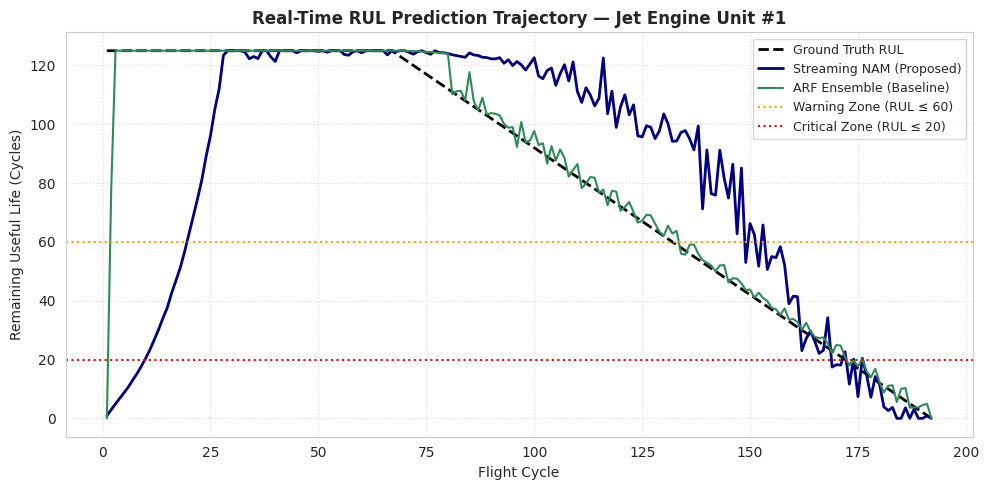

In [ ]:
# Run this code block in your notebook to generate the Lifetime Trajectory plot
unit1_mask = (df_clean['unit_number'] == 1)
unit1_true = y_raw[unit1_mask]
unit1_nam_preds = np.array(eval_logs['streaming_nam']['preds'])[unit1_mask]
unit1_arf_preds = np.array(eval_logs['arf_ensemble']['preds'])[unit1_mask]
cycles = df_clean.loc[unit1_mask, 'time_cycle'].values

plt.figure(figsize=(10, 5))
plt.plot(cycles, unit1_true, label='Ground Truth RUL', color='black', linestyle='--', linewidth=2)
plt.plot(cycles, unit1_nam_preds, label='Streaming NAM (Proposed)', color='navy', linewidth=2)
plt.plot(cycles, unit1_arf_preds, label='ARF Ensemble (Baseline)', color='seagreen', linewidth=1.5)

# Highlight warning and critical operational zones
plt.axhline(y=60, color='orange', linestyle=':', label='Warning Zone (RUL ≤ 60)')
plt.axhline(y=20, color='red', linestyle=':', label='Critical Zone (RUL ≤ 20)')

plt.title('Real-Time RUL Prediction Trajectory — Jet Engine Unit #1', fontsize=12, fontweight='bold')
plt.xlabel('Flight Cycle', fontsize=10)
plt.ylabel('Remaining Useful Life (Cycles)', fontsize=10)
plt.legend(fontsize=9, loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

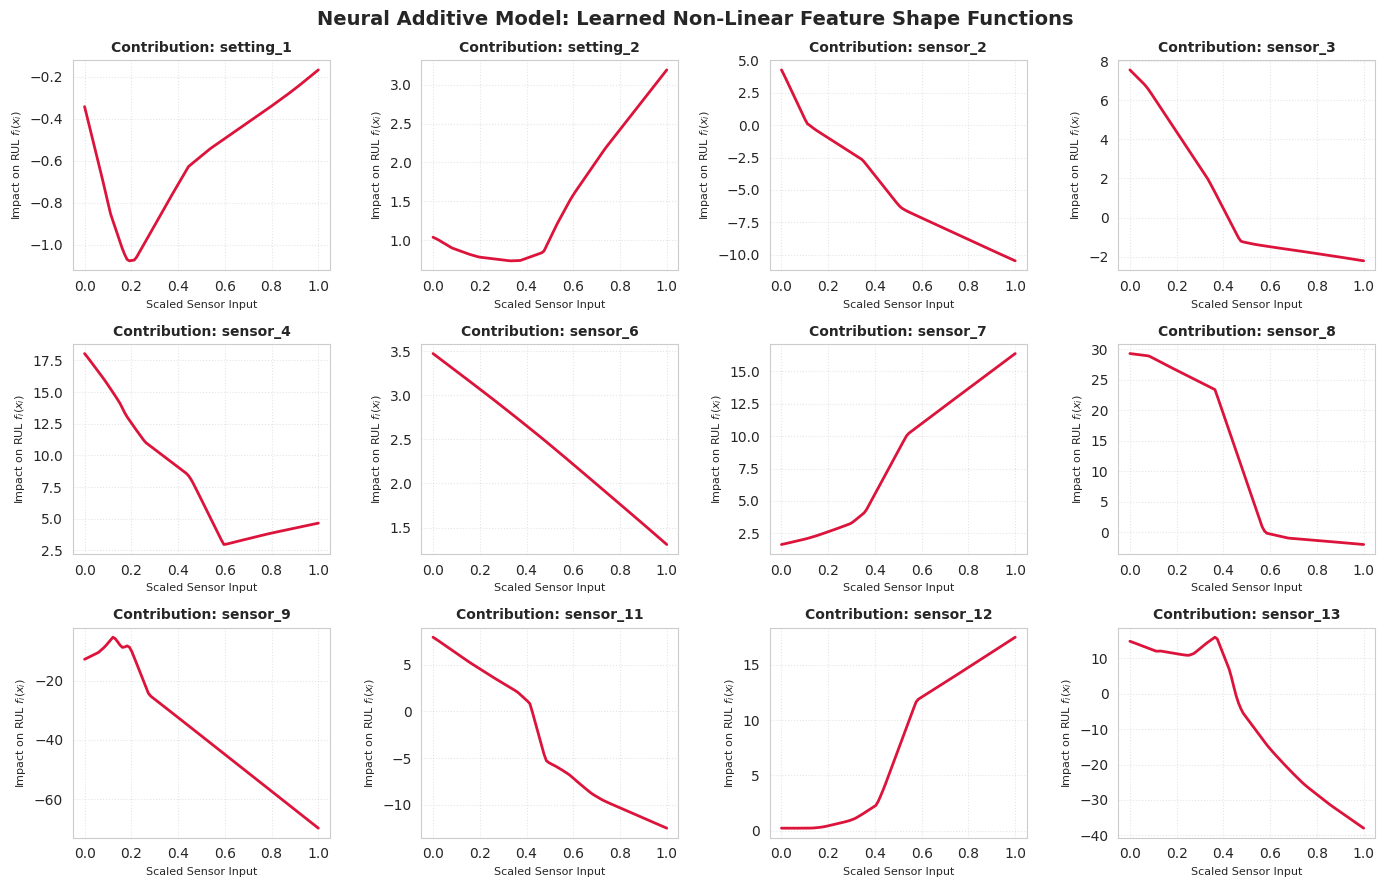

In [ ]:
# Plot feature shape functions to prove interpretability
streaming_nam.eval()
fig, axes = plt.subplots(3, 4, figsize=(14, 9))
axes = axes.flatten()

x_grid = torch.linspace(0, 1, 100).unsqueeze(1)

with torch.no_grad():
    for i, feature_name in enumerate(active_features[:12]):
        sub_net = streaming_nam.feature_nets[i]
        contribution = sub_net(x_grid).squeeze().numpy()

        axes[i].plot(x_grid.numpy(), contribution, color='crimson', linewidth=2)
        axes[i].set_title(f"Contribution: {feature_name}", fontsize=10, fontweight='bold')
        axes[i].set_xlabel("Scaled Sensor Input", fontsize=8)
        axes[i].set_ylabel("Impact on RUL $f_i(x_i)$", fontsize=8)
        axes[i].grid(True, linestyle=':', alpha=0.5)

plt.suptitle("Neural Additive Model: Learned Non-Linear Feature Shape Functions", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
!pip install gradio -q
import gradio as gr

def predict_telemetry(*sensor_values):
    # Convert input array and scale
    raw_inputs = np.array(sensor_values, dtype=np.float64)
    scaled_inputs = (raw_inputs - X_min) / (X_max - X_min)
    x_tensor = torch.tensor(scaled_inputs, dtype=torch.float32).unsqueeze(0)

    streaming_nam.eval()
    with torch.no_grad():
        pred_rul, _ = streaming_nam(x_tensor)
        rul_val = max(0.0, min(125.0, pred_rul.item()))

    if rul_val <= 20:
        status = "🔴 CRITICAL STATUS: Immediate Maintenance Required"
    elif rul_val <= 60:
        status = "🟠 WARNING PHASE: Schedule Inspection Soon"
    else:
        status = "🟢 STABLE OPERATION: Engine Health Normal"

    return round(rul_val, 2), status

# Create dynamic input sliders for top sensors
inputs = [gr.Slider(float(X_min[i]), float(X_max[i]), value=float(X_min[i]), label=feat) for i, feat in enumerate(active_features)]

demo = gr.Interface(
    fn=predict_telemetry,
    inputs=inputs,
    outputs=[gr.Number(label="Predicted RUL (Cycles)"), gr.Textbox(label="Operational Status")],
    title="Real-Time Jet Engine Prognostics (Streaming NAM)",
    description="Adjust telemetry inputs to inspect real-time RUL estimation and failure warning triggers."
)

demo.launch(share=True) # Generates a public link for live demos!

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://75a5d4970f9b0df6ea.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
